# Initial Analysis: Foreign Gifts 
# Ciarra Barnett

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as nppd
import seaborn as sns
import plotly.graph_objects as go


gifts = pd.read_csv("ForeignGifts_edu.csv")
gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [57]:
gifts.shape

(28221, 10)

In [58]:
gifts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28221 entries, 0 to 28220
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          28221 non-null  int64 
 1   OPEID                       28221 non-null  int64 
 2   Institution Name            28221 non-null  object
 3   City                        28221 non-null  object
 4   State                       28221 non-null  object
 5   Foreign Gift Received Date  28221 non-null  int64 
 6   Foreign Gift Amount         28221 non-null  int64 
 7   Gift Type                   28221 non-null  object
 8   Country of Giftor           28221 non-null  object
 9   Giftor Name                 24470 non-null  object
dtypes: int64(4), object(6)
memory usage: 2.2+ MB


In [59]:
gifts["Gift Type"].value_counts()


Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

In [60]:
gifts.groupby ("Gift Type")["Foreign Gift Amount"].agg(["count","sum", "mean", "median"])

,count,sum,mean,median
Gift Type,,,,
Contract,17274,10809974431,6.257945e+05,110000.0
Monetary Gift,10936,5775853163,5.281504e+05,50000.0
Real Estate,11,14687920,1.335265e+06,667555.0


## Gift Type Analysis 
 Contracts are the most common gift type and is the most expensive total amount of foreign funding. Monntary gift are also pretty common and has a lower average and median than contracts. Real estate gifts are the lowest and rare but they do have the highest average gift amount. 

In [61]:
country_totals = gifts.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
country_totals.sort_values(ascending=False).head(10)

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
CANADA           898160656
HONG KONG        887402529
JAPAN            655954776
SWITZERLAND      619899445
INDIA            539556490
Name: Foreign Gift Amount, dtype: int64

## Country givinig the most money
Qatar gives the most foreign funding in the dataset with 2,706,240,869 in total gifts. 

In [62]:
gifts["Country of Giftor"].value_counts().head(10)

Country of Giftor
ENGLAND         3655
CHINA           2461
CANADA          2344
JAPAN           1896
SWITZERLAND     1676
SAUDI ARABIA    1610
FRANCE          1437
GERMANY         1394
HONG KONG       1080
SOUTH KOREA      811
Name: count, dtype: int64

## Country with Most Gifts
England has the  greatest number of gifts with 3.655 gift records. 

In [63]:
country_average = gifts. groupby("Country of Giftor")["Foreign Gift Amount"].mean()
country_average.sort_values(ascending=False).head(10)


Country of Giftor
BERMUDA     7.688837e+06
ECUADOR     3.985140e+06
QATAR       3.905109e+06
ANTIGUA     3.435545e+06
JERSEY      3.064589e+06
MOROCCO     2.740214e+06
RUSSIA      2.025462e+06
GUERNSEY    1.750000e+06
IRAQ        1.665520e+06
CYPRUS      1.562512e+06
Name: Foreign Gift Amount, dtype: float64

## Country with Largest Average Gift
Bermuda has the largest average gift amount at 7,688,837 per gift. 

In [64]:
institution_totals = gifts.groupby("Institution Name")["Foreign Gift Amount"].sum()
institution_totals.sort_values(ascending=False).head(10)

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
Texas A&M University                      521455050
Johns Hopkins University                  502409595
Northwestern University                   402316221
Georgetown University                     379950511
University of Chicago (The)               364544338
Name: Foreign Gift Amount, dtype: int64

## Institution receiving the most money 
Carnegie Mellon University receives the largest total amount of foregin funding. 

In [65]:
gifts["Institution Name"].value_counts().head(10)

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
University of Michigan - Ann Arbor              715
Stanford University                             668
Cornell University                              653
University of Pennsylvania                      625
Massachusetts Institute of Technology           582
Name: count, dtype: int64

## Institution receiving the most gifts 
UCLA receives the greatest amount of gifts with 3,916 records. 

In [66]:
top_20 =(gifts.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(20))
top_20.reset_index()

,Institution Name,Foreign Gift Amount
0,Carnegie Mellon University,1477922504
1,Cornell University,1289937761
2,Harvard University,954803610
3,Massachusetts Institute of Technology,859071692
4,Yale University,613441311
5,Texas A&M University,521455050
6,Johns Hopkins University,502409595
7,Northwestern University,402316221
8,Georgetown University,379950511
9,University of Chicago (The),364544338


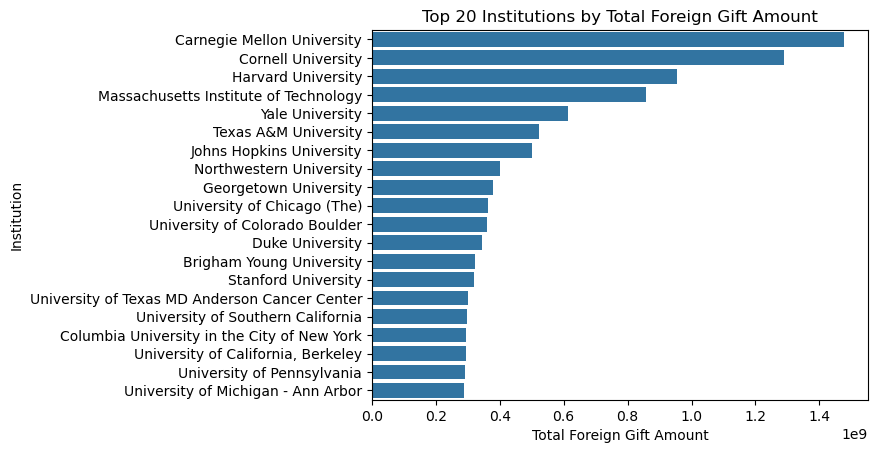

In [71]:
top_20 = (
gifts.groupby("Institution Name")["Foreign Gift Amount"]
.sum()
.sort_values(ascending=False)
.head(20)
.reset_index()
)

sns.barplot(
data=top_20,
x="Foreign Gift Amount",
y="Institution Name"
)

plt.title("Top 20 Institutions by Total Foreign Gift Amount")
plt.xlabel("Total Foreign Gift Amount")
plt.ylabel("Institution")
plt.show()



In [77]:
university_totals = (
    gifts.groupby("Institution Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

In [78]:
mean_amount = university_totals["Foreign Gift Amount"].mean()
median_amount = university_totals["Foreign Gift Amount"].median()

print("Mean:", mean_amount)
print("Median:", median_amount)

Mean: 52202878.974842764
Median: 6486791.5


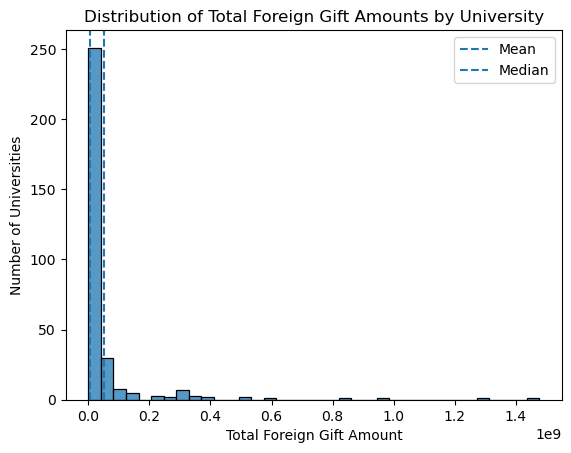

In [83]:
university_totals = (gifts.groupby("Institution Name")["Foreign Gift Amount"]
    .sum())

mean_amount = university_totals.mean()
median_amount = university_totals.median()

sns.histplot(university_totals)

plt.axvline(mean_amount, linestyle="--", label="Mean")
plt.axvline(median_amount, linestyle="--", label="Median")

plt.title("Distribution of Total Foreign Gift Amounts by University")
plt.xlabel("Total Foreign Gift Amount")
plt.ylabel("Number of Universities")
plt.legend()

plt.show()

## Distrubution of foreign gift amounts 
The ditrubtuion of total foreign gift amounts received by universities is right skewed. Most universities receive relatively smaller amount of foreign funding while smaller institutions receive extremely large amounts. So this causes the mean to be much hhigher than the median. 

In [86]:
country_institution = pd.crosstab(gifts["Country of Giftor"], gifts["Institution Name"],values = gifts["Foreign Gift Amount"], aggfunc = "sum")
country_institution = country_institution.fillna(0)

largest_flow = country_institution.stack().sort_values(ascending=False)
largest_flow.head(10)

Country of Giftor     Institution Name              
QATAR                 Cornell University                1.018473e+09
BERMUDA               Carnegie Mellon University        7.500000e+08
QATAR                 Texas A&M University              5.040994e+08
                      Carnegie Mellon University        4.254107e+08
                      Georgetown University             3.271283e+08
                      Northwestern University           3.111486e+08
CANADA                Brigham Young University          2.599278e+08
UNITED ARAB EMIRATES  University of Colorado Boulder    2.197348e+08
ENGLAND               Harvard University                1.883283e+08
HONG KONG             Yale University                   1.611312e+08
dtype: float64

## What is the largest flow of a single country to a single institution? 
QATAR to  Cornell University totaling about 1.018 billion to foreign funding. 


In [95]:
top_flows = largest_flow.head(10).reset_index() 
top_flows.columns = ["Country ", "Institution ", "Amount"]
top_flows

,Country,Institution,Amount
0,QATAR,Cornell University,1.018473e+09
1,BERMUDA,Carnegie Mellon University,7.500000e+08
2,QATAR,Texas A&M University,5.040994e+08
3,QATAR,Carnegie Mellon University,4.254107e+08
4,QATAR,Georgetown University,3.271283e+08
5,QATAR,Northwestern University,3.111486e+08
6,CANADA,Brigham Young University,2.599278e+08
7,UNITED ARAB EMIRATES,University of Colorado Boulder,2.197348e+08
8,ENGLAND,Harvard University,1.883283e+08
9,HONG KONG,Yale University,1.611312e+08


In [97]:
countries = top_flows["Country "]. unique(). tolist()
institutions = top_flows["Institution "]. unique(). tolist()
labels = countries + institutions

In [100]:
source = top_flows["Country "].apply(lambda x: labels.index(x)).tolist()
target = top_flows["Institution "].apply(lambda x: labels.index(x)).tolist()

In [105]:

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()


## Which are the top giftors to U.S academic institutions?
The top giftors to U.S academic instituions were indentified by grouping the data by giftor name and calculting the total amount donated but each giftor. The results show that a small number of giftors contribute a large portion of the overall foreign funding received by U.S. academic institutions